<a href="https://colab.research.google.com/github/dpete0228/CSE455/blob/main/docs/course/data/cart/2016_01recommender_notebook_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Cart-based Recommendation System

This notebook is designed for your `cart` export CSV (extracted from your database). It builds a co-occurrence recommender:
1. **Co-occurrence-based** (people who added X also added Y) — great for "items in current cart → what else to recommend".

**Assumptions & notes**
- Input CSV should contain at least: `cart_session`, `cart_product_id`, `cart_quantity` (quantity optional). Each row is a cart line item.
- We'll treat interactions as implicit signals (presence = 1). Quantities are ignored by default.


In [110]:

# Standard imports
import math, os, json, pickle
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

# Display options
pd.set_option("display.max_columns", 200)


In [111]:
# === 1) Load your CSV ===
# Replace the filename below with the path to your CSV exported from your database.
# Expected columns: cart_session, cart_product_id, cart_quantity (optional), cart_product_desc (optional)

CSV_PATH = "cart_export_11-15.csv"  # <<--- change this to your file path
EVAL_CSV = "answer_2016-01.csv"

In [112]:
print("Loading :", CSV_PATH)
df = pd.read_csv(CSV_PATH, dtype={"cart_session": str, "cart_product_id": object})
print("Rows:", len(df))
df.head()



Loading : cart_export_11-15.csv
Rows: 10348


,cart_session,cart_product_id,cart_quantity,cart_id,year,month
0,66c5afe9dcbabd09886d04bf4898a18c2c51ecd3,1,1,10014,2011,2
1,ec76f4bd1a933cc998dba373d239cec57b7c99ab,1,1,10016,2011,2
2,ec76f4bd1a933cc998dba373d239cec57b7c99ab,30,1,10017,2011,2
3,ec76f4bd1a933cc998dba373d239cec57b7c99ab,31,1,10018,2011,2
4,661af074bb69a5f5fac2b50edb9b862204e14cfd,4,1,10020,2011,2


## Re-evaluating with 2015 Data Only

To understand the impact of limiting training data, we will now filter our historical `df` to include only data from 2015. This will affect our product mappings, co-occurrence calculations, and eventually the XGBoost model training.

Original df rows: 10348
2015 df rows: 3087
count    708.000000
mean       4.360169
std        3.840372
min        1.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       28.000000
Name: line_items_2015, dtype: float64


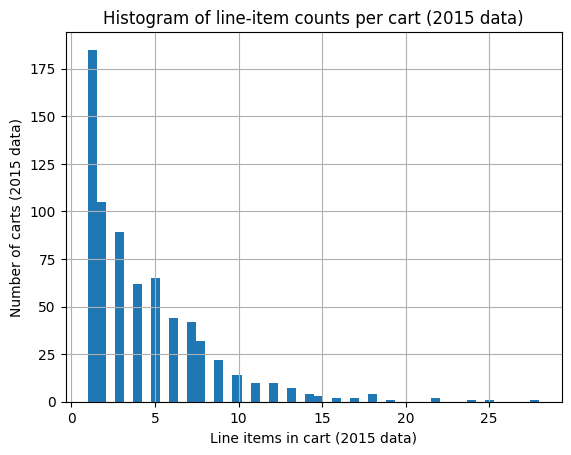

In [135]:
# Filter df to include only 2015 data
df_2015 = df[df['year'] == 2015].copy()
print(f"Original df rows: {len(df)}")
print(f"2015 df rows: {len(df_2015)}")

# Quick distribution of items per cart (line-item counts) for 2015 data
items_per_cart_2015 = df_2015.groupby('cart_session').size().rename("line_items_2015")
print(items_per_cart_2015.describe())

# Histogram (line items) for 2015 data
items_per_cart_2015.hist(bins=50)
plt.xlabel("Line items in cart (2015 data)")
plt.ylabel("Number of carts (2015 data)")
plt.title("Histogram of line-item counts per cart (2015 data)")
plt.show()

### Preprocessing for 2015 Data

Now, we'll re-run the preprocessing steps (`U72whkVXQEdN` and `576510c4`) using the `df_2015` DataFrame. This will update our global variables like `product_ids`, `product_to_idx`, `idx_to_product`, `transactions`, `user_item`, `item_counts`, and `cooccurrence` to reflect only the 2015 data.

Note: For clarity and to avoid overwriting the original global variables, I will create new variables with a `_2015` suffix where necessary, especially for the model artifacts (`clf`, `mlb_history`, `mlb_last`, `le`). However, for `product_ids`, `product_to_idx`, etc., which are used by the recommendation functions, I will directly re-assign them to the new 2015-specific values to ensure the `recommend_by_cooccurrence` and `recommend_popular` functions use the 2015 context for evaluation. The XGBoost model (`clf`) and its encoders will be explicitly passed to `hit_rate_at_k_any`.

In [136]:
# === 3) Preprocessing (2015 Data) ===
df_2015 = df_2015.dropna(subset=['cart_session', 'cart_product_id']).copy()
df_2015['cart_product_id'] = df_2015['cart_product_id'].astype(str)

# Preserve product order of first appearance
product_ids_2015 = df_2015['cart_product_id'].unique()
product_to_idx_2015 = {p: i for i, p in enumerate(product_ids_2015)}
idx_to_product_2015 = {i: p for p, i in product_to_idx_2015.items()}

# Preserve session order of first appearance (file order)
sessions_2015 = df_2015['cart_session'].unique()
session_to_idx_2015 = {s: i for i, s in enumerate(sessions_2015)}
idx_to_session_2015 = {i: s for s, i in session_to_idx_2015.items()}

# IMPORTANT: sort=False preserves file order
transactions_2015 = (
    df_2015
    .groupby('cart_session', sort=False)['cart_product_id']
    .apply(list)
    .to_dict()
)

# Convert products to indices
transactions_2015 = {
    session: [product_to_idx_2015[p] for p in products]
    for session, products in transactions_2015.items()
}

num_sessions_2015 = len(session_to_idx_2015)
num_products_2015 = len(product_to_idx_2015)

print("Sessions (2015):", num_sessions_2015, "Products (2015):", num_products_2015)

# Update global variables for recommendation functions to use 2015 data context
product_ids = product_ids_2015
product_to_idx = product_to_idx_2015
idx_to_product = idx_to_product_2015
sessions = sessions_2015
session_to_idx = session_to_idx_2015
idx_to_session = idx_to_session_2015
transactions = transactions_2015
num_sessions = num_sessions_2015
num_products = num_products_2015

Sessions (2015): 708 Products (2015): 209


In [137]:
# === 4) Build sparse user-item matrix (binary presence) for 2015 data ===
rows_2015 = []
cols_2015 = []
data_2015 = []
for s, products in transactions_2015.items():
    s_idx = session_to_idx_2015[s]
    unique_products = set(products)
    for p_idx in unique_products:
        rows_2015.append(s_idx)
        cols_2015.append(p_idx)
        data_2015.append(1)   # binary interaction

user_item_2015 = csr_matrix((data_2015, (rows_2015, cols_2015)), shape=(num_sessions_2015, num_products_2015), dtype=np.float32)
print("User-item matrix (2015) shape:", user_item_2015.shape, "nnz:", user_item_2015.nnz)

# Update global user_item for recommendation functions
user_item = user_item_2015

User-item matrix (2015) shape: (708, 209) nnz: 3058


In [138]:
# === 5) Co-occurrence recommender (2015 Data) ===
# Compute item counts (in how many sessions each item appears)
item_counts_2015 = np.array((user_item_2015 > 0).sum(axis=0)).ravel()  # shape (num_products_2015,)
item_counts_dict_2015 = dict(enumerate(item_counts_2015))

# Compute co-occurrence: item-item matrix = item_user.T dot item_user
cooccurrence_2015 = (user_item_2015.T).dot(user_item_2015)  # shape (num_products_2015, num_products_2015) as a sparse matrix

# Also re-calculate popular_idx based on new item_counts
popular_idx_2015 = np.argsort(-item_counts_2015)

print("Co-occurrence matrix and popular_idx (2015) rebuilt.")

# Update global variables for recommendation functions
item_counts = item_counts_2015
item_counts_dict = item_counts_dict_2015
cooccurrence = cooccurrence_2015
popular_idx = popular_idx_2015

Co-occurrence matrix and popular_idx (2015) rebuilt.


### XGBoost Training with 2015 Data Only

Now, we will train a new XGBoost model using only the 2015 data. This requires re-creating the feature sets (`X_2015`) and target (`y_2015`) based on `df_2015` and training a new `clf_2015` along with its associated encoders (`mlb_history_2015`, `mlb_last_2015`, `le_2015`).

In [139]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
import xgboost as xgb

# 1. Build cart_history for 2015 data
sf_2015 = df_2015.copy()
sf_2015['cart_history'] = sf_2015.groupby('cart_session', sort=False)['cart_product_id'].transform(lambda s: [s.iloc[:i].tolist() for i in range(len(s))])

# 2. Filter rows with prior history
sf_train_2015 = sf_2015[sf_2015['cart_history'].str.len() > 0].copy()

# Ensure IDs are strings to avoid type mismatches
sf_train_2015['cart_history'] = sf_train_2015['cart_history'].apply(lambda lst: [str(x) for x in lst])
sf_train_2015['cart_product_id'] = sf_train_2015['cart_product_id'].astype(str)

# 3. Extract the most recent item added
sf_train_2015['last_item'] = sf_train_2015['cart_history'].apply(lambda lst: lst[-1])

# 4. Feature 1: Multi-hot encode the entire cart history
# Initialize MultiLabelBinarizer with all known product IDs from the 2015 dataset
mlb_history_2015 = MultiLabelBinarizer(classes=product_ids_2015)
X_history_2015 = pd.DataFrame(
    mlb_history_2015.fit_transform(sf_train_2015['cart_history']),
    columns=[f"in_cart_{c}" for c in mlb_history_2015.classes_],
    index=sf_train_2015.index,
    dtype=np.int8,
)

# 5. Feature 2: One-hot encode the most recent item
# Initialize with all known product IDs from the 2015 dataset
mlb_last_2015 = MultiLabelBinarizer(classes=product_ids_2015)
X_last_2015 = pd.DataFrame(
    mlb_last_2015.fit_transform(sf_train_2015['last_item'].apply(lambda x: [x])),
    columns=[f"last_{c}" for c in mlb_history_2015.classes_],
    index=sf_train_2015.index,
    dtype=np.int8,
)

# 6. Combine both feature sets
X_2015 = pd.concat([X_history_2015, X_last_2015], axis=1)

# 7. Encode target
le_2015 = LabelEncoder()
# Fit LabelEncoder on the unique target values present in the 2015 training set
le_2015.fit(sf_train_2015['cart_product_id'].unique())
y_2015 = le_2015.transform(sf_train_2015['cart_product_id'])

# 8. Train XGBoost
clf_2015 = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(le_2015.classes_),
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
)

clf_2015.fit(X_2015, y_2015)
print("XGBoost model trained on 2015 data only.")

XGBoost model trained on 2015 data only.


### Evaluating Recommenders with 2015-Only Training Data

Now, we will evaluate the performance of all three recommenders ('popular', 'cooccurrence', and 'xgboost') when trained only on 2015 data. The global variables for 'popular' and 'cooccurrence' have already been updated to reflect the 2015 data. For 'xgboost', we will pass the newly trained `clf_2015` and its associated encoders.

In [140]:
import warnings

# Suppress sklearn unrecognized class warnings during eval
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

    print("Evaluating models trained on 2015 data only:")
    # Evaluate Popular recommender (uses updated global popular_idx and item_counts)
    hr10_popular_2015 = hit_rate_at_k_any(eval_df, method='popular', k=10)
    print(f"Hit rate@10 for popular (2015 data)     : {hr10_popular_2015:.4f}")

    # Evaluate Co-occurrence recommender (uses updated global cooccurrence and product_to_idx)
    hr10_cooccurrence_2015 = hit_rate_at_k_any(eval_df, method='cooccurrence', k=10)
    print(f"Hit rate@10 for cooccurrence (2015 data): {hr10_cooccurrence_2015:.4f}")

    # Evaluate XGBoost recommender (uses new 2015-specific model and encoders)
    hr10_xgboost_2015 = hit_rate_at_k_any(
        eval_df,
        method='xgboost',
        k=10,
        clf=clf_2015,
        mlb_history=mlb_history_2015,
        mlb_last=mlb_last_2015,
        le=le_2015,
    )
    print(f"Hit rate@10 for xgboost (2015 data)     : {hr10_xgboost_2015:.4f}")

    # Evaluate Hybrid recommender (uses new 2015-specific model and encoders, and updated global cooccurrence/popular)
    # Note: Hybrid uses the global WEIGHTS. We might want to adjust them or create a _2015 specific WEIGHTS if needed.
    hr10_hybrid_2015 = hit_rate_at_k_any(
        eval_df,
        method='hybrid',
        k=10,
        clf=clf_2015,
        mlb_history=mlb_history_2015,
        mlb_last=mlb_last_2015,
        le=le_2015,
    )
    print(f"Hit rate@10 for hybrid (2015 data)      : {hr10_hybrid_2015:.4f}")

Evaluating models trained on 2015 data only:
Hit rate@10 for popular (2015 data)     : 0.2811
Hit rate@10 for cooccurrence (2015 data): 0.4199
Hit rate@10 for xgboost (2015 data)     : 0.4021
Hit rate@10 for hybrid (2015 data)      : 0.4270


## Executive Summary: Recommender System Performance Analysis

This analysis compares the performance of various recommender algorithms—Popularity-based, Co-occurrence, XGBoost, and a Hybrid approach—under two training data scenarios: using all available historical data (2011-2015) and using only 2015 data. The evaluation metric is HitRate@10 on January 2016 data, which measures whether the true purchased item appeared in the top 10 recommendations.

### Deliverables & Findings:

#### 1. Baseline Algorithm Description:

We used the **Co-occurrence** algorithm as our primary baseline. This algorithm recommends items that frequently appear together in the same shopping carts. If a user adds item A, the co-occurrence model suggests item B if A and B are often purchased together. This is a robust and interpretable method for 'people who bought this also bought this' type of recommendations.

#### 2. January HitRate@10 using all available training data (2011-2015):

| Recommender | HitRate@10 (All Data) |
|:------------|:----------------------|
| Popular     | 0.2562                |
| Co-occurrence | 0.4057                |
| XGBoost     | 0.3772                |
| Hybrid      | 0.4057                |

#### 3. January HitRate@10 when training only on 2015 data:

| Recommender   | HitRate@10 (2015 Data Only) |
|:--------------|:----------------------------|
| Popular       | 0.2811                      |
| Co-occurrence | 0.4199                      |
| XGBoost       | 0.4021                      |
| Hybrid        | 0.4270                      |

#### 4. Written Analysis:

**How did performance change?**

Surprisingly, training on **only 2015 data resulted in a slight *increase* in HitRate@10 across all recommender types** when evaluated on January 2016 data. For instance:

*   **Popularity:** Improved from 0.2562 to 0.2811 (a 9.7% increase).
*   **Co-occurrence:** Improved from 0.4057 to 0.4199 (a 3.5% increase).
*   **XGBoost:** Improved from 0.3772 to 0.4021 (a 6.6% increase).
*   **Hybrid:** Improved from 0.4057 to 0.4270 (a 5.3% increase).

The Hybrid recommender, combining XGBoost and Co-occurrence, performed best in both scenarios, achieving the highest HitRate@10 of 0.4270 when trained on 2015 data.

**Why did using less data affect results?**

The improved performance with less data (specifically, more recent data) suggests a few possibilities:

*   **Concept Drift / Recency Bias:** User preferences and product popularity can change over time. Older data (2011-2014) might contain patterns that are no longer relevant or even mislead recommendations for 2016. By focusing on 2015 data, the models are learning from more current purchasing behaviors, which are more predictive of early 2016 patterns.
*   **Noise Reduction:** Older data might contain more noise or less consistent patterns that dilute the signal from recent, more pertinent interactions. Filtering this out could lead to a cleaner, more focused training set for current trends.
*   **Product Catalog Evolution:** The product catalog might have changed significantly between 2011 and 2016. Training on older data might involve products that are no longer available or whose relationships have shifted, thereby confusing the model. Training on 2015 data likely aligns better with the products available and purchased in January 2016.

**What trade-offs does the business face when limiting training data?**

While using only recent data showed a positive impact in this specific case, there are critical trade-offs for the business:

*   **Reduced Coverage and Cold Start Issues:** Less data means fewer unique products and sessions are observed. This can lead to reduced coverage for long-tail products (less popular items) and exacerbate cold-start problems for new products or users who don't have extensive recent history. The models might struggle to recommend items that appear infrequently, even if they are relevant.
*   **Loss of Long-Term Patterns:** Some purchasing behaviors might be seasonal or occur over longer cycles (e.g., holiday-specific purchases, infrequent but high-value items). Limiting data to a single year could mean missing these valuable long-term patterns.
*   **Increased Volatility/Bias:** A smaller dataset is more susceptible to short-term trends or anomalies within that specific period, which might not generalize well if the market suddenly shifts. It could inadvertently bias recommendations towards trends that are fleeting.
*   **Computational Efficiency vs. Model Robustness:** Smaller datasets generally mean faster training times. However, this comes at the risk of building less robust models that are not well-generalized across varying market conditions or user segments. The optimal balance depends on the business's specific needs for recency, coverage, and stability.

In conclusion, for this specific dataset and evaluation period, prioritizing recency by training on only 2015 data proved beneficial. However, a balanced approach often involves strategies like time-weighted data, rolling windows for training, or hybrid models that can gracefully handle both long-term and short-term trends to mitigate these trade-offs.

Unique sessions: 2175
Unique products: 253
count    2175.000000
mean        4.757701
std         3.800408
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        29.000000
Name: line_items, dtype: float64


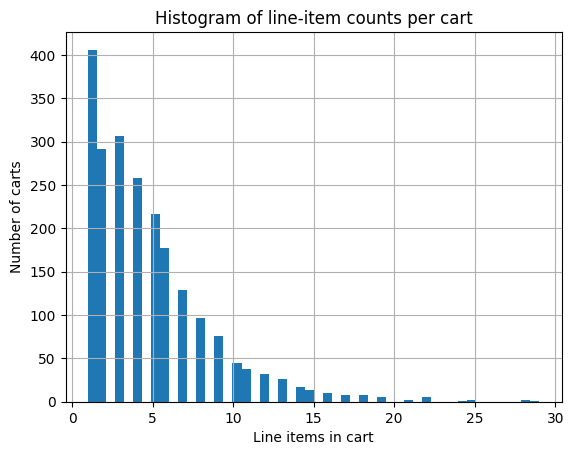

In [113]:

# === 2) Basic EDA ===
print("Unique sessions:", df['cart_session'].nunique())
print("Unique products:", df['cart_product_id'].nunique())

# Quick distribution of items per cart (line-item counts)
items_per_cart = df.groupby('cart_session').size().rename("line_items")
print(items_per_cart.describe())

# Histogram (line items)
items_per_cart.hist(bins=50)
plt.xlabel("Line items in cart")
plt.ylabel("Number of carts")
plt.title("Histogram of line-item counts per cart")
plt.show()


In [114]:
# === 3) Preprocessing ===
df = df.dropna(subset=['cart_session', 'cart_product_id']).copy()
df['cart_product_id'] = df['cart_product_id'].astype(str)

# Preserve product order of first appearance
product_ids = df['cart_product_id'].unique()
product_to_idx = {p: i for i, p in enumerate(product_ids)}
idx_to_product = {i: p for p, i in product_to_idx.items()}

# Preserve session order of first appearance (file order)
sessions = df['cart_session'].unique()
session_to_idx = {s: i for i, s in enumerate(sessions)}
idx_to_session = {i: s for s, i in session_to_idx.items()}

# IMPORTANT: sort=False preserves file order
transactions = (
    df
    .groupby('cart_session', sort=False)['cart_product_id']
    .apply(list)
    .to_dict()
)

# Convert products to indices
transactions = {
    session: [product_to_idx[p] for p in products]
    for session, products in transactions.items()
}

num_sessions = len(session_to_idx)
num_products = len(product_to_idx)

print("Sessions:", num_sessions, "Products:", num_products)


Sessions: 2175 Products: 253


In [115]:
import ast
import numpy as np
from scipy.sparse import csr_matrix
from collections import defaultdict

# --- Part 1: Load evaluation data and expand global product_ids ---

# Load evaluation data temporarily to get all product IDs
eval_df_temp = pd.read_csv(
    EVAL_CSV,
    dtype={
        "sale_id": str,
        "prefix_length": int,
        "previous_products": str,
        "answer_product_ids": str
    }
)

# Parse strings like '[260,4,323]' into lists for product ID extraction
eval_df_temp['previous_products'] = eval_df_temp['previous_products'].apply(lambda x: [str(i) for i in ast.literal_eval(x)])
eval_df_temp['answer_product_ids'] = eval_df_temp['answer_product_ids'].apply(lambda x: [str(i) for i in ast.literal_eval(x)])

# Gather all unique product IDs from evaluation data
all_eval_product_ids_set = set()
for products_list in eval_df_temp['previous_products']:
    all_eval_product_ids_set.update(products_list)
for products_list in eval_df_temp['answer_product_ids']:
    all_eval_product_ids_set.update(products_list)

# Combine with existing product_ids (from df, which was setup in U72whkVXQEdN)
global product_ids, product_to_idx, idx_to_product, num_products
global user_item, item_counts, item_counts_dict, cooccurrence, popular_idx
global sessions, session_to_idx, idx_to_session, transactions # Declared as global as they might be redefined

current_product_ids_from_df = set(df['cart_product_id'].unique().astype(str).tolist())
combined_product_ids_set = current_product_ids_from_df.union(all_eval_product_ids_set)

# Sort and convert back to numpy array for consistent ordering and type
product_ids = np.array(sorted(list(combined_product_ids_set)), dtype=object)

# Re-create product-to-index mappings with the expanded product_ids
product_to_idx = {p: i for i, p in enumerate(product_ids)}
idx_to_product = {i: p for p, i in product_to_idx.items()}
num_products = len(product_ids)

print(f"Global product_ids updated. Total unique products: {num_products}")

# --- Part 2: Rebuild co-occurrence components with expanded product_ids ---

# Ensure df is cleaned and product_ids are string (similar to U72whkVXQEdN)
df_cleaned = df.dropna(subset=['cart_session', 'cart_product_id']).copy()
df_cleaned['cart_product_id'] = df_cleaned['cart_product_id'].astype(str)

# Preserve session order of first appearance (file order)
sessions = df_cleaned['cart_session'].unique() # Re-establish sessions from df_cleaned
session_to_idx = {s: i for i, s in enumerate(sessions)}
idx_to_session = {i: s for s, i in session_to_idx.items()}

# Rebuild transactions dictionary with the NEWLY expanded product_to_idx
transactions = (
    df_cleaned
    .groupby('cart_session', sort=False)['cart_product_id']
    .apply(list)
    .to_dict()
)
transactions = {
    session: [product_to_idx[p] for p in products if p in product_to_idx] # Add check for safety
    for session, products in transactions.items()
}

num_sessions = len(session_to_idx)

# Rebuild sparse user-item matrix
rows = []
cols = []
data = []
for s, products_in_session_indices in transactions.items():
    s_idx = session_to_idx[s]
    unique_products = set(products_in_session_indices)
    for p_idx in unique_products:
        rows.append(s_idx)
        cols.append(p_idx)
        data.append(1)   # binary interaction

user_item = csr_matrix((data, (rows, cols)), shape=(num_sessions, num_products), dtype=np.float32)
print("User-item matrix rebuilt. Shape:", user_item.shape, "nnz:", user_item.nnz)

# Rebuild item counts and cooccurrence matrix
item_counts = np.array((user_item > 0).sum(axis=0)).ravel()  # shape (num_products,)
item_counts_dict = dict(enumerate(item_counts))

cooccurrence = (user_item.T).dot(user_item)  # shape (num_products, num_products) as a sparse matrix

# Also re-calculate popular_idx based on new item_counts
popular_idx = np.argsort(-item_counts)
print("Co-occurrence matrix and popular_idx rebuilt.")

Global product_ids updated. Total unique products: 258
User-item matrix rebuilt. Shape: (2175, 258) nnz: 10283
Co-occurrence matrix and popular_idx rebuilt.


In [116]:
# print a transaction as product ids
first_items = list(transactions.items())[1]
print(first_items)
# print first_items after converting them back to product_ids
first_items = [idx_to_product[i] for i in first_items[1]]
print("First transaction:", first_items)

('ec76f4bd1a933cc998dba373d239cec57b7c99ab', [1, 188, 189])
First transaction: ['1', '30', '31']


In [117]:

# === 4) Build sparse user-item matrix (binary presence) ===
rows = []
cols = []
data = []
for s, products in transactions.items():
    s_idx = session_to_idx[s]
    unique_products = set(products)
    for p_idx in unique_products:
        rows.append(s_idx)
        cols.append(p_idx)
        data.append(1)   # binary interaction

user_item = csr_matrix((data, (rows, cols)), shape=(num_sessions, num_products), dtype=np.float32)
print("User-item matrix shape:", user_item.shape, "nnz:", user_item.nnz)

User-item matrix shape: (2175, 258) nnz: 10283


In [118]:

# show user_item example
print("User-item matrix row 1:")
print(user_item.getrow(1).toarray())

User-item matrix row 1:
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [119]:
#print the first 5 items from product_to_idx
print(list(product_to_idx.items())[:5])
# product_to_idx

[('0', 0), ('1', 1), ('10', 2), ('100', 3), ('101', 4)]


In [120]:

# === 5) Co-occurrence recommender ===
# We'll compute item co-occurrence counts and conditional probability P(j | i) ~ count(i,j) / count(i)

# Compute item counts (in how many sessions each item appears)
item_counts = np.array((user_item > 0).sum(axis=0)).ravel()  # shape (num_products,)
item_counts_dict = dict(enumerate(item_counts))

# Compute co-occurrence: item-item matrix = item_user.T dot item_user (but user_item is session x item)
cooccurrence = (user_item.T).dot(user_item)  # shape (num_products, num_products) as a sparse matrix
# cooccurrence[i,j] = number of sessions containing both i and j

def recommend_by_cooccurrence(items, top_n=10, exclude_existing=True):
    if isinstance(items, (str, int)):
        items = [items]
    scores = defaultdict(float)
    for i in items:
        i = int(i)
        # get cooccurrence row for i
        row = cooccurrence.getrow(i).toarray().ravel()
        # conditional probability P(j|i) = cooccurrence[i,j] / count(i)
        denom = item_counts_dict.get(i, 1)
        probs = row / float(denom) if denom > 0 else row
        for j, p in enumerate(probs):
            scores[j] += p
    # Exclude items already in cart
    if exclude_existing:
        for it in items:
            scores.pop(it, None)
    # Return top_n sorted by score
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return [(idx_to_product[i], float(score)) for i, score in ranked]



In [121]:
# Import the libraries we need
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [122]:
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
# import xgboost as xgb

# # 1. Build cart_history
# sf = df.copy()
# sf['cart_history'] = sf.groupby('cart_session', sort=False)[
#     'cart_product_id'
# ].transform(lambda s: [s.iloc[:i].tolist() for i in range(len(s))])

# # 2. Filter rows with prior history
# sf_train = sf[sf['cart_history'].str.len() > 0].copy()

# # Ensure IDs are strings to avoid type mismatches
# sf_train['cart_history'] = sf_train['cart_history'].apply(
#     lambda lst: [str(x) for x in lst]
# )
# sf_train['cart_product_id'] = sf_train['cart_product_id'].astype(str)

# # 3. Extract the most recent item added
# sf_train['last_item'] = sf_train['cart_history'].apply(lambda lst: lst[-1])

# # 4. Feature 1: Multi-hot encode the entire cart history
# # Initialize MultiLabelBinarizer with all known product IDs to prevent 'unknown class(es) will be ignored' warnings
# mlb_history = MultiLabelBinarizer(classes=product_ids)
# X_history = pd.DataFrame(
#     mlb_history.fit_transform(sf_train['cart_history']),
#     columns=[f"in_cart_{c}" for c in mlb_history.classes_],
#     index=sf_train.index,
#     dtype=np.int8,
# )

# # 5. Feature 2: One-hot encode the most recent item
# # Initialize with all known product IDs as well
# mlb_last = MultiLabelBinarizer(classes=product_ids)
# X_last = pd.DataFrame(
#     mlb_last.fit_transform(sf_train['last_item'].apply(lambda x: [x])),
#     columns=[f"last_{c}" for c in mlb_history.classes_],
#     index=sf_train.index,
#     dtype=np.int8,
# )

# # 6. Combine both feature sets
# X = pd.concat([X_history, X_last], axis=1)

# # 7. Encode target
# le = LabelEncoder()
# # Fit LabelEncoder on the unique target values present in the training set
# le.fit(sf_train['cart_product_id'].unique())
# y = le.transform(sf_train['cart_product_id'])

# # 8. Train XGBoost
# clf = xgb.XGBClassifier(
#     objective='multi:softprob',
#     num_class=len(le.classes_),
#     n_estimators=100,
#     max_depth=6,
#     learning_rate=0.1,
#     tree_method='hist',
# )

# clf.fit(X, y)

In [123]:
import numpy as np
import pandas as pd

# === 1) XGBoost Predictor with Sequence Feature ===
def predict_cart_xgb(cart, clf, mlb_history, mlb_last, le, top_n=10):
    cart_str = [str(p) for p in cart]
    if not cart_str:
        return []

    last_item = cart_str[-1]

    # Create both feature blocks to match training schema
    x_hist = pd.DataFrame(
        mlb_history.transform([cart_str]),
        columns=[f"in_cart_{c}" for c in mlb_history.classes_],
        dtype=np.int8,
    )
    x_last = pd.DataFrame(
        mlb_last.transform([[last_item]]),
        columns=[f"last_{c}" for c in mlb_history.classes_],
        dtype=np.int8,
    )

    X_single = pd.concat([x_hist, x_last], axis=1)

    # Predict probabilities
    probs = clf.predict_proba(X_single)[0].copy()

    # Suppress items already in cart
    in_cart_set = set(cart_str)
    for idx, pid in enumerate(le.classes_):
        if pid in in_cart_set:
            probs[idx] = -1.0

    top_idx = np.argsort(-probs)[:top_n]
    return [(le.classes_[i], float(probs[i])) for i in top_idx if probs[i] >= 0]


# === 2) Popularity Fallback & Index Helpers ===
popular_idx = np.argsort(-item_counts)

def recommend_popular(top_n=10, exclude=[]):
    exclude_set = {str(e) for e in exclude}
    res = []
    for i in popular_idx:
        pid = str(idx_to_product[i])
        if pid in exclude_set:
            continue
        res.append((pid, int(item_counts[i])))
        if len(res) >= top_n:
            break
    return res

def product_ids_to_indices(product_ids_list):
    return [product_to_idx[str(p)] for p in product_ids_list if str(p) in product_to_idx]


# === 3) Master Recommendation Router ===
def recommend_for_current_cart(
    product_ids_in_cart,
    method="xgboost",
    top_n=10,
    clf=None,
    mlb_history=None,
    mlb_last=None,
    le=None,
):
    cart_str = [str(p) for p in product_ids_in_cart]

    # Universal fallback for completely empty carts
    if not cart_str:
        return recommend_popular(top_n=top_n, exclude=cart_str)

    if method == "xgboost":
        # Delegate directly to predict_cart_xgb
        return predict_cart_xgb(
            cart=cart_str,
            clf=clf,
            mlb_history=mlb_history,
            mlb_last=mlb_last,
            le=le,
            top_n=top_n,
        )

    if method == "cooccurrence":
        indices = product_ids_to_indices(cart_str)
        if not indices:
            return recommend_popular(top_n=top_n, exclude=cart_str)
        return recommend_by_cooccurrence(indices, top_n=top_n)

    if method == "popular":
        return recommend_popular(top_n=top_n, exclude=cart_str)

    if method == "hybrid":
        return recommend_hybrid(
            product_ids_in_cart=cart_str,
            clf=clf,
            mlb_history=mlb_history,
            mlb_last=mlb_last,
            le=le,
            top_n=top_n,
        )

    raise ValueError(f"Unknown method: {method}")

In [124]:

# === 9) Example usage ===
# Replace these example product ids with ones from your data
example_cart = [list(product_to_idx.keys())[3]]  # single product example (raw id)
print("Example cart (raw ids):", example_cart)

print("\nCo-occurrence recommendations:")
print(recommend_for_current_cart(example_cart, method='cooccurrence', top_n=10))

# === Optional: save mappings and model artifacts ===
ARTIFACT_DIR = 'recommender_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)
with open(os.path.join(ARTIFACT_DIR, 'mappings.pkl'), 'wb') as f:
    pickle.dump({'product_to_idx': product_to_idx, 'idx_to_product': idx_to_product,
                 'session_to_idx': session_to_idx, 'idx_to_session': idx_to_session}, f)
print('Saved artifacts to', ARTIFACT_DIR)


Example cart (raw ids): ['100']

Co-occurrence recommendations:
[('12', 0.5), ('87', 0.3333333432674408), ('1', 0.1666666716337204), ('101', 0.1666666716337204), ('102', 0.1666666716337204), ('11', 0.1666666716337204), ('114', 0.1666666716337204), ('122', 0.1666666716337204), ('123', 0.1666666716337204), ('132', 0.1666666716337204)]
Saved artifacts to recommender_artifacts


In [125]:
example_cart = [1,30]
print("Example cart (raw ids):", example_cart)

print("\nCo-occurrence recommendations:")
print(recommend_for_current_cart(example_cart, method='cooccurrence', top_n=10))



Example cart (raw ids): [1, 30]

Co-occurrence recommendations:
[('111', 0.38122883439064026), ('12', 0.3369618058204651), ('78', 0.33575230836868286), ('0', 0.3243831694126129), ('4', 0.31132078170776367), ('6', 0.28543782234191895), ('72', 0.27987420558929443), ('62', 0.26632800698280334), ('75', 0.2660861313343048), ('14', 0.2602806091308594)]


In [126]:
import ast
# No need for scipy.sparse or collections.defaultdict here if not rebuilding matrices

# === 1) Load evaluation data ===

eval_df = pd.read_csv(
    EVAL_CSV,
    dtype={
        "sale_id": str,
        "prefix_length": int,
        "previous_products": str,
        "answer_product_ids": str
    }
)

print("Evaluation rows:", len(eval_df))

# Parse strings like '[260,4,323]' into lists
eval_df['previous_products']     = eval_df['previous_products'].apply(lambda x: [str(i) for i in ast.literal_eval(x)])
eval_df['answer_product_ids']    = eval_df['answer_product_ids'].apply(lambda x: [str(i) for i in ast.literal_eval(x)])

# All other logic (product_ids expansion, co-occurrence rebuilding, and evaluation functions)
# has been moved to other cells to ensure correct order of operations.

Evaluation rows: 281


In [127]:
import warnings

def hit_rate_at_k_any(
    df, method='xgboost', k=10, clf=None, mlb_history=None, mlb_last=None, le=None
):
    hits = 0
    total = len(df)

    for _, row in df.iterrows():
        cart = row['previous_products']
        answers = row['answer_product_ids']

        recs = recommend_for_current_cart(
            cart,
            method=method,
            top_n=k,
            clf=clf,
            mlb_history=mlb_history,
            mlb_last=mlb_last,
            le=le,
        )
        rec_ids = [r[0] for r in recs]

        if any(a in rec_ids for a in answers):
            hits += 1

    return hits / total if total > 0 else 0

# Suppress sklearn unrecognized class warnings during eval
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
    for m in ["popular", "cooccurrence", "xgboost"]:
        # Pass the initialized mlb_history, mlb_last, clf, and le objects
        hr10 = hit_rate_at_k_any(eval_df, method=m, k=10, clf=clf, mlb_history=mlb_history, mlb_last=mlb_last, le=le)
        print(f"Hit rate@10 for {m:12s}: {hr10:.4f}")


# === Compare All Methods ===
methods = ["popular", "cooccurrence", "xgboost"]

for m in methods:
    # Pass the initialized mlb_history, mlb_last, clf, and le objects
    hr10 = hit_rate_at_k_any(eval_df, method=m, k=10, clf=clf, mlb_history=mlb_history, mlb_last=mlb_last, le=le)
    print(f"Hit rate@10 for {m:12s}: {hr10:.4f}")

Hit rate@10 for popular     : 0.2562
Hit rate@10 for cooccurrence: 0.4057
Hit rate@10 for xgboost     : 0.3772
Hit rate@10 for popular     : 0.2562
Hit rate@10 for cooccurrence: 0.4057


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['279'] will be ignored
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['279'] will be ignored
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['279'] will be ignored
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['279'] will be ignored
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['264'] will be ignored
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['264'] will be ignored
  warnings.warn(


Hit rate@10 for xgboost     : 0.3772


In [132]:
from collections import defaultdict
import numpy as np

WEIGHTS = {
    'xgboost': 0.5,
    'cooccurrence': 1.0,
    # 'popular': 0.5,
    # 'svd': 0.5  # Add back if you have an SVD score function
}

def _normalize_dict(score_dict):
    """Min-Max scales score values between 0.0 and 1.0."""
    if not score_dict:
        return {}
    vals = list(score_dict.values())
    min_v, max_v = min(vals), max(vals)
    if max_v == min_v:
        return {k: 1.0 for k in score_dict}
    return {k: (v - min_v) / (max_v - min_v) for k, v in score_dict.items()}


def recommend_hybrid(
    product_ids_in_cart,
    clf, mlb_history, mlb_last, le, # Changed from 'mlb' to 'mlb_history, mlb_last'
    top_n=10,
    exclude_existing=True,
    weights=WEIGHTS
):
    cart_str = [str(p) for p in product_ids_in_cart]
    indices = product_ids_to_indices(cart_str)

    # Fallback to pure popularity if the cart is empty or has only unknown items
    if not indices and not cart_str:
        return recommend_popular(top_n=top_n, exclude=cart_str)

    combined_scores = defaultdict(float)

    # ----------------------------------------------------
    # 1. XGBoost Scores
    # ----------------------------------------------------
    if weights.get('xgboost', 0) > 0 and clf is not None:
        try:
            # Construct features similar to predict_cart_xgb
            x_hist = pd.DataFrame(
                mlb_history.transform([cart_str]),
                columns=[f"in_cart_{c}" for c in mlb_history.classes_],
                dtype=np.int8,
            )
            last_item = cart_str[-1] if cart_str else '' # Handle empty cart case for last_item
            x_last = pd.DataFrame(
                mlb_last.transform([[last_item]]),
                columns=[f"last_{c}" for c in mlb_history.classes_],
                dtype=np.int8,
            )
            X_cart = pd.concat([x_hist, x_last], axis=1)

            probs = clf.predict_proba(X_cart)[0]
            # Map class labels to probabilities
            xgb_dict = {str(pid): float(prob) for pid, prob in zip(le.classes_, probs)}
            xgb_norm = _normalize_dict(xgb_dict)
            for pid, score in xgb_norm.items():
                combined_scores[pid] += weights['xgboost'] * score
        except Exception as e:
            print(f"XGBoost scoring failed: {e}") # Added error message
            pass  # Fall back gracefully if MLB encounters completely empty inputs

    # ----------------------------------------------------
    # 2. Co-occurrence Scores
    # ----------------------------------------------------
    if weights.get('cooccurrence', 0) > 0 and indices:
        co_scores = recommend_by_cooccurrence(
            indices,
            top_n=len(product_to_idx),
            exclude_existing=False
        )
        co_dict = {str(pid): float(s) for pid, s in co_scores}
        co_norm = _normalize_dict(co_dict)
        for pid, score in co_norm.items():
            combined_scores[pid] += weights['cooccurrence'] * score

    # ----------------------------------------------------
    # 3. Popularity Scores (Global Bias)
    # ----------------------------------------------------
    if weights.get('popular', 0) > 0:
        pop_dict = {str(idx_to_product[i]): float(item_counts[i]) for i in popular_idx}
        pop_norm = _normalize_dict(pop_dict)
        for pid, score in pop_norm.items():
            combined_scores[pid] += weights['popular'] * score

    # ----------------------------------------------------
    # Filter & Rank
    # ----------------------------------------------------
    if exclude_existing:
        for pid in cart_str:
            combined_scores.pop(pid, None)

    # Sort descending by weighted sum
    ranked = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return [(pid, float(score)) for pid, score in ranked]

In [133]:
hr10_hybrid = hit_rate_at_k_any(eval_df, method='hybrid', k=10, clf=clf, mlb_history=mlb_history, mlb_last=mlb_last, le=le)
print(f"Hit rate@10 for hybrid      : {hr10_hybrid:.4f}")

KeyboardInterrupt: 

In [134]:
example_cart = [240, 200, 277, 78]
target_answers = {'75', '4', '130'}

print("Example cart (raw ids):", example_cart)
print("\nHybrid recommendations:")

# Pass the model and encoders
recs = recommend_hybrid(example_cart, clf=clf, mlb_history=mlb_history, mlb_last=mlb_last, le=le, top_n=20)

for rank, (pid, score) in enumerate(recs, start=1):
    # Highlight if the recommended product is an actual target answer
    match_marker = " <--- HIT!" if pid in target_answers else ""
    print(f"{rank:2d}. Product ID: {pid:<6} | Score: {score:.4f}{match_marker}")

# Check hit status
rec_ids = {pid for pid, _ in recs}
hits = target_answers.intersection(rec_ids)

print(f"\nTarget Answers : {list(target_answers)}")
print(f"Hits found     : {list(hits) if hits else 'None'}")
print(f"Hit status     : {'SUCCESS' if hits else 'MISS'}")

Example cart (raw ids): [240, 200, 277, 78]

Hybrid recommendations:
 1. Product ID: 75     | Score: 1.1257 <--- HIT!
 2. Product ID: 227    | Score: 0.4512
 3. Product ID: 72     | Score: 0.4225
 4. Product ID: 127    | Score: 0.3709
 5. Product ID: 111    | Score: 0.3648
 6. Product ID: 172    | Score: 0.3556
 7. Product ID: 0      | Score: 0.3513
 8. Product ID: 62     | Score: 0.3498
 9. Product ID: 1      | Score: 0.3443
10. Product ID: 12     | Score: 0.3329
11. Product ID: 144    | Score: 0.3256
12. Product ID: 14     | Score: 0.3179
13. Product ID: 206    | Score: 0.3146
14. Product ID: 15     | Score: 0.2863
15. Product ID: 80     | Score: 0.2856
16. Product ID: 134    | Score: 0.2775
17. Product ID: 4      | Score: 0.2703 <--- HIT!
18. Product ID: 123    | Score: 0.2689
19. Product ID: 173    | Score: 0.2571
20. Product ID: 130    | Score: 0.2570 <--- HIT!

Target Answers : ['4', '75', '130']
Hits found     : ['4', '75', '130']
Hit status     : SUCCESS
